In [ ]:
import os
import io
import json
import time
import copy
import random
import warnings
import shutil
import h5py
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

from torchvision import models
from torchvision.models import MobileNet_V3_Small_Weights, MobileNet_V3_Large_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, matthews_corrcoef, cohen_kappa_score,
    balanced_accuracy_score, precision_recall_curve,
    brier_score_loss, auc
)

warnings.filterwarnings("ignore")

In [ ]:
COLAB_INPUT = "/kaggle/input/competitions/isic-2024-challenge"
TRAIN_HDF5 = f"{COLAB_INPUT}/train-image.hdf5"
INDEX_PATH = "/kaggle/input/datasets/snehalnaik71/kaggledatasetversion/final_dataset_index_fixed.csv"

In [ ]:
SAVE_DIR = "/kaggle/working/mobilenetv3_fusion_224"
BEST_MODEL_PATH = os.path.join(SAVE_DIR, "mobilenetv3_fusion_best.pth")
LAST_CHECKPOINT_PATH = os.path.join(SAVE_DIR, "checkpoint_last.pth")
METRICS_JSON_PATH = os.path.join(SAVE_DIR, "final_metrics.json")
HISTORY_CSV_PATH = os.path.join(SAVE_DIR, "training_history.csv")
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
CONFIG = {
    "img_size": 224,
    "batch_size": 16,
    "epochs": 25,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "patience": 3,
    "num_workers": 4,
    "pin_memory": True,
    "amp": True,
    "dropout": 0.3,
    "meta_hidden": 64,
    "fusion_hidden": 256,
    "target_sensitivity": 0.90,
    "resume_checkpoint": None,

    # choose one:
    "backbone_name": "mobilenetv3_small",   # "mobilenetv3_small" or "mobilenetv3_large"
}

In [ ]:
def compute_pauc(y_true, y_prob, min_tpr=0.80):
    y_true = np.asarray(y_true).flatten()
    y_prob = np.asarray(y_prob).flatten()

    v_gt = np.abs(y_true - 1)
    v_pred = -1.0 * y_prob

    fpr, tpr, _ = roc_curve(v_gt, v_pred)
    max_fpr = abs(1 - min_tpr)

    stop = np.searchsorted(fpr, max_fpr, "right")
    if stop == len(fpr):
        return float(auc(fpr, tpr))

    x_interp = [fpr[stop - 1], fpr[stop]]
    y_interp = [tpr[stop - 1], tpr[stop]]

    tpr = np.append(tpr[:stop], np.interp(max_fpr, x_interp, y_interp))
    fpr = np.append(fpr[:stop], max_fpr)

    partial_auc = float(auc(fpr, tpr))
    return partial_auc

In [ ]:
def compute_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp + 1e-8)

In [ ]:
def threshold_at_sensitivity(y_true, y_prob, min_sensitivity=0.90):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    valid = np.where(tpr >= min_sensitivity)[0]
    if len(valid) == 0:
        j = np.argmax(tpr - fpr)
        return float(thresholds[j])
    best_idx = valid[np.argmin(fpr[valid])]
    return float(thresholds[best_idx])


def threshold_best_f1(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    thresholds = np.append(thresholds, 1.0)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    idx = np.argmax(f1)
    return float(thresholds[idx]), float(f1[idx])

def evaluate_predictions(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_sensitivity": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(compute_specificity(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "auroc": float(roc_auc_score(y_true, y_prob)),
        "ap": float(average_precision_score(y_true, y_prob)),
        "pauc@80tpr": float(compute_pauc(y_true, y_prob, min_tpr=0.80)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "kappa": float(cohen_kappa_score(y_true, y_pred)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }
    return metrics, cm


def print_metrics(title, metrics):
        print(f"\n{'=' * 80}")
        print(title)
        print(f"{'=' * 80}")
        for k, v in metrics.items():
            if k in ["tn", "fp", "fn", "tp"]:
                print(f"{k:>22}: {v}")
            else:
                print(f"{k:>22}: {v:.6f}" if isinstance(v, float) else f"{k:>22}: {v}")

In [ ]:
class MetadataPreprocessor:
    def __init__(self):
        self.age_median = None
        self.age_min = None
        self.age_max = None
        self.size_median = None
        self.size_q99 = None
        self.site_cols = None

    def fit(self, df):
        df = df.copy()
        self.age_median = float(df["age_approx"].median())
        age_filled = df["age_approx"].fillna(self.age_median)
        self.age_min = float(age_filled.min())
        self.age_max = float(age_filled.max())

        if "clin_size_long_diam_mm" in df.columns:
            size_series = df["clin_size_long_diam_mm"]
            self.size_median = float(size_series.median()) if size_series.notna().any() else 0.0
            self.size_q99 = float(size_series.quantile(0.99)) if size_series.notna().any() else 1.0
        else:
            self.size_median = 0.0
            self.size_q99 = 1.0

        site_series = df["anatom_site_general"].fillna("unknown").astype(str)
        self.site_cols = sorted(site_series.unique().tolist())
        return self

    def transform(self, df):
        df = df.copy()
        df["age_approx"] = df["age_approx"].fillna(self.age_median)
        df["age_approx"] = (df["age_approx"] - self.age_min) / (self.age_max - self.age_min + 1e-8)

        df["sex_missing"] = df["sex"].isna().astype(np.float32)
        df["sex"] = df["sex"].map({"male": 0.0, "female": 1.0}).fillna(0.5)

        if "clin_size_long_diam_mm" in df.columns:
            df["clin_size_long_diam_mm"] = df["clin_size_long_diam_mm"].fillna(self.size_median)
            df["clin_size_long_diam_mm"] = df["clin_size_long_diam_mm"].clip(0, self.size_q99) / (self.size_q99 + 1e-8)
        else:
            df["clin_size_long_diam_mm"] = 0.0

        site = df["anatom_site_general"].fillna("unknown").astype(str)
        for col in self.site_cols:
            df[f"site_{col}"] = (site == col).astype(np.float32)

        meta_cols = ["age_approx", "sex", "sex_missing", "clin_size_long_diam_mm"] + [f"site_{c}" for c in self.site_cols]
        for c in meta_cols:
            if c not in df.columns:
                df[c] = 0.0
        return df, meta_cols

In [ ]:
class ISICFusionDataset(Dataset):
    def __init__(self, df, hdf5_path, meta_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.hdf5_path = hdf5_path
        self.meta_cols = meta_cols
        self.transform = transform
        self._h5 = None

    def _get_h5(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.hdf5_path, "r")
        return self._h5

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        isic_id = row["isic_id"]

        h5 = self._get_h5()
        raw = h5[isic_id][()]
        image = np.array(Image.open(io.BytesIO(raw)).convert("RGB"))

        if self.transform is not None:
            image = self.transform(image=image)["image"]

        meta = torch.tensor(row[self.meta_cols].values.astype(np.float32), dtype=torch.float32)
        label = torch.tensor(float(row["target"]), dtype=torch.float32)
        return image, meta, label

train_tf = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=25, border_mode=0, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.20, contrast_limit=0.20, p=0.6),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=0, border_mode=0, p=0.4),
    A.CLAHE(clip_limit=2.0, p=0.4),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.GaussNoise(p=0.3),
    A.CoarseDropout(num_holes_range=(4, 10), hole_height_range=(16, 32), hole_width_range=(16, 32), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


In [ ]:
class MobileNetV3Fusion(nn.Module):
    def __init__(self, meta_dim, backbone_name="mobilenetv3_small", dropout=0.3, meta_hidden=64, fusion_hidden=256):
        super().__init__()

        if backbone_name == "mobilenetv3_small":
            backbone = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
            in_features = backbone.classifier[0].in_features
        elif backbone_name == "mobilenetv3_large":
            backbone = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)
            in_features = backbone.classifier[0].in_features
        else:
            raise ValueError("backbone_name must be 'mobilenetv3_small' or 'mobilenetv3_large'")

        backbone.classifier = nn.Identity()
        self.backbone = backbone

        self.image_proj = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.Hardswish(),
            nn.Dropout(dropout),
        )

        self.meta_net = nn.Sequential(
            nn.Linear(meta_dim, meta_hidden),
            nn.BatchNorm1d(meta_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(meta_hidden, 64),
            nn.ReLU(inplace=True),
        )

        self.gate = nn.Sequential(
            nn.Linear(256 + 64, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 256),
            nn.Sigmoid(),
        )

        self.meta_to_img = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 + 64, fusion_hidden),
            nn.BatchNorm1d(fusion_hidden),
            nn.Hardswish(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, 1),
        )

    def forward(self, image, meta):
        img_feat = self.backbone(image)
        img_feat = self.image_proj(img_feat)

        meta_feat = self.meta_net(meta)
        meta_as_img = self.meta_to_img(meta_feat)

        gate = self.gate(torch.cat([img_feat, meta_feat], dim=1))
        gated_img = gate * img_feat + (1.0 - gate) * meta_as_img

        fused = torch.cat([gated_img, meta_feat], dim=1)
        logits = self.classifier(fused).squeeze(1)
        return logits

In [ ]:
def run_epoch_train(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss = 0.0
    all_probs, all_labels = [], []

    pbar = tqdm(loader, desc="Train", leave=False)
    for images, meta, labels in pbar:
        images = images.to(DEVICE, non_blocking=True)
        meta = meta.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=CONFIG["amp"] and DEVICE.type == "cuda"):
            logits = model(images, meta)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.detach().cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels).astype(int)
    return running_loss / len(loader.dataset), all_labels, all_probs

@torch.no_grad()
def run_epoch_eval(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_probs, all_labels = [], []

    pbar = tqdm(loader, desc="Eval", leave=False)
    for images, meta, labels in pbar:
        images = images.to(DEVICE, non_blocking=True)
        meta = meta.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with autocast(enabled=CONFIG["amp"] and DEVICE.type == "cuda"):
            logits = model(images, meta)
            loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels).astype(int)
    return running_loss / len(loader.dataset), all_labels, all_probs

In [ ]:
def save_checkpoint(path, epoch, model, optimizer, scheduler, scaler, best_val_auroc, history, meta_cols, preprocessor_state):
    state = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
        "scaler_state": scaler.state_dict(),
        "best_val_auroc": best_val_auroc,
        "history": history,
        "meta_cols": meta_cols,
        "preprocessor_state": preprocessor_state,
        "config": CONFIG,
        "seed": SEED,
    }
    torch.save(state, path)

def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
    if scaler is not None and "scaler_state" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state"])
    return ckpt

In [ ]:
assert os.path.exists(INDEX_PATH), f"Missing INDEX_PATH: {INDEX_PATH}"
assert os.path.exists(TRAIN_HDF5), f"Missing TRAIN_HDF5: {TRAIN_HDF5}"

df = pd.read_csv(INDEX_PATH)
print("Full dataframe shape:", df.shape)

train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()

if "patient_id" in df.columns:
    train_pats = set(train_df["patient_id"].unique())
    val_pats = set(val_df["patient_id"].unique())
    overlap = len(train_pats & val_pats)
    print(f"Patient overlap between train/val: {overlap}")

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Train malignant: {int(train_df['target'].sum())}")

Full dataframe shape: (401059, 8)
Patient overlap between train/val: 0
Train: 298560 | Val: 53629 | Test: 48870
Train malignant: 271


In [ ]:
preprocessor = MetadataPreprocessor().fit(train_df)
train_df, meta_cols = preprocessor.transform(train_df)
val_df, _ = preprocessor.transform(val_df)
test_df, _ = preprocessor.transform(test_df)

print("Metadata features:", meta_cols)
print("Meta dim:", len(meta_cols))

preprocessor_state = {
    "age_median": preprocessor.age_median,
    "age_min": preprocessor.age_min,
    "age_max": preprocessor.age_max,
    "size_median": preprocessor.size_median,
    "size_q99": preprocessor.size_q99,
    "site_cols": preprocessor.site_cols,
}

train_dataset = ISICFusionDataset(train_df, TRAIN_HDF5, meta_cols, transform=train_tf)
val_dataset = ISICFusionDataset(val_df, TRAIN_HDF5, meta_cols, transform=val_tf)
test_dataset = ISICFusionDataset(test_df, TRAIN_HDF5, meta_cols, transform=val_tf)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"],
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"],
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"],
    persistent_workers=True
)

Metadata features: ['age_approx', 'sex', 'sex_missing', 'clin_size_long_diam_mm', 'site_anterior torso', 'site_head/neck', 'site_lower extremity', 'site_posterior torso', 'site_unknown', 'site_upper extremity']
Meta dim: 10


In [ ]:
model = MobileNetV3Fusion(
    meta_dim=len(meta_cols),
    backbone_name=CONFIG["backbone_name"],
    dropout=CONFIG["dropout"],
    meta_hidden=CONFIG["meta_hidden"],
    fusion_hidden=CONFIG["fusion_hidden"],
).to(DEVICE)

num_pos = float(train_df["target"].sum())
num_neg = float((train_df["target"] == 0).sum())
pos_weight = torch.tensor([max(num_neg / (num_pos + 1e-8), 1.0)], device=DEVICE)
print("pos_weight:", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
scaler = GradScaler(enabled=CONFIG["amp"] and DEVICE.type == "cuda")

pos_weight: 1100.6973876953125


In [ ]:
start_epoch = 1
best_val_auroc = -np.inf
history = []

resume_path = CONFIG["resume_checkpoint"]
if resume_path and os.path.exists(resume_path):
    ckpt = load_checkpoint(resume_path, model, optimizer, scheduler, scaler)
    start_epoch = ckpt["epoch"] + 1
    best_val_auroc = ckpt.get("best_val_auroc", -np.inf)
    history = ckpt.get("history", [])
    print(f"Resumed at epoch {start_epoch}")

best_state = None
epochs_no_improve = 0

for epoch in range(start_epoch, CONFIG["epochs"] + 1):
    print(f"\nEpoch {epoch}/{CONFIG['epochs']}")

    train_loss, y_train, p_train = run_epoch_train(model, train_loader, optimizer, criterion, scaler)
    val_loss, y_val, p_val = run_epoch_eval(model, val_loader, criterion)

    val_threshold_sens = threshold_at_sensitivity(y_val, p_val, CONFIG["target_sensitivity"])
    val_metrics_sens, _ = evaluate_predictions(y_val, p_val, val_threshold_sens)

    val_threshold_f1, _ = threshold_best_f1(y_val, p_val)
    val_metrics_f1, _ = evaluate_predictions(y_val, p_val, val_threshold_f1)

    current_val_auroc = val_metrics_sens["auroc"]
    scheduler.step(current_val_auroc)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_auroc": val_metrics_sens["auroc"],
        "val_ap": val_metrics_sens["ap"],
        "val_pauc": val_metrics_sens["pauc@80tpr"],
        "val_sensitivity_thr": val_threshold_sens,
        "val_sensitivity": val_metrics_sens["recall_sensitivity"],
        "val_specificity": val_metrics_sens["specificity"],
        "val_f1_at_sens_thr": val_metrics_sens["f1"],
        "val_best_f1_thr": val_threshold_f1,
        "val_best_f1": val_metrics_f1["f1"],
    }
    history.append(row)
    pd.DataFrame(history).to_csv(HISTORY_CSV_PATH, index=False)

    print(f"Train loss: {train_loss:.6f} | Val loss: {val_loss:.6f}")
    print_metrics("Validation @ sensitivity threshold", val_metrics_sens)
    print_metrics("Validation @ best F1", val_metrics_f1)

    save_checkpoint(
        LAST_CHECKPOINT_PATH, epoch, model, optimizer, scheduler, scaler,
        best_val_auroc, history, meta_cols, preprocessor_state
    )

    epoch_ckpt = os.path.join(SAVE_DIR, f"checkpoint_epoch_{epoch:02d}.pth")
    save_checkpoint(
        epoch_ckpt, epoch, model, optimizer, scheduler, scaler,
        best_val_auroc, history, meta_cols, preprocessor_state
    )

    if current_val_auroc > best_val_auroc:
        best_val_auroc = current_val_auroc
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, BEST_MODEL_PATH)
        print(f"New best model saved (AUROC {best_val_auroc:.5f})")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= CONFIG["patience"]:
        print("Early stopping triggered.")
        break


Epoch 1/25


Train loss: 1.651701 | Val loss: 1.180601

Validation @ sensitivity threshold
             threshold: 0.424805
              accuracy: 0.685692
     balanced_accuracy: 0.798866
             precision: 0.003076
    recall_sensitivity: 0.912281
           specificity: 0.685451
                    f1: 0.006132
                 auroc: 0.874104
                    ap: 0.012618
            pauc@80tpr: 0.110464
                   mcc: 0.041922
                 kappa: 0.004022
                 brier: 0.169128
                    tn: 36721
                    fp: 16851
                    fn: 5
                    tp: 52

Validation @ best F1
             threshold: 0.897949
              accuracy: 0.991348
     balanced_accuracy: 0.583827
             precision: 0.023419
    recall_sensitivity: 0.175439
           specificity: 0.992216
                    f1: 0.041322
                 auroc: 0.874104
                    ap: 0.012618
            pauc@80tpr: 0.110464
                   mcc: 0.06

Train loss: 1.144907 | Val loss: 1.136648

Validation @ sensitivity threshold
             threshold: 0.244141
              accuracy: 0.627123
     balanced_accuracy: 0.769550
             precision: 0.002594
    recall_sensitivity: 0.912281
           specificity: 0.626820
                    f1: 0.005174
                 auroc: 0.859154
                    ap: 0.010401
            pauc@80tpr: 0.101661
                   mcc: 0.036309
                 kappa: 0.003061
                 brier: 0.106770
                    tn: 33580
                    fp: 19992
                    fn: 5
                    tp: 52

Validation @ best F1
             threshold: 0.952637
              accuracy: 0.990378
     balanced_accuracy: 0.592105
             precision: 0.022869
    recall_sensitivity: 0.192982
           specificity: 0.991227
                    f1: 0.040892
                 auroc: 0.859154
                    ap: 0.010401
            pauc@80tpr: 0.101661
                   mcc: 0.06

Train loss: 1.160136 | Val loss: 0.902325

Validation @ sensitivity threshold
             threshold: 0.298340
              accuracy: 0.518861
     balanced_accuracy: 0.715362
             precision: 0.002012
    recall_sensitivity: 0.912281
           specificity: 0.518442
                    f1: 0.004014
                 auroc: 0.887663
                    ap: 0.025103
            pauc@80tpr: 0.111482
                   mcc: 0.028088
                 kappa: 0.001897
                 brier: 0.163258
                    tn: 27774
                    fp: 25798
                    fn: 5
                    tp: 52

Validation @ best F1
             threshold: 0.979004
              accuracy: 0.997054
     balanced_accuracy: 0.560396
             precision: 0.060870
    recall_sensitivity: 0.122807
           specificity: 0.997984
                    f1: 0.081395
                 auroc: 0.887663
                    ap: 0.025103
            pauc@80tpr: 0.111482
                   mcc: 0.08

Train loss: 1.168209 | Val loss: 0.761673

Validation @ sensitivity threshold
             threshold: 0.343994
              accuracy: 0.767290
     balanced_accuracy: 0.839708
             precision: 0.004151
    recall_sensitivity: 0.912281
           specificity: 0.767136
                    f1: 0.008264
                 auroc: 0.922928
                    ap: 0.026274
            pauc@80tpr: 0.139870
                   mcc: 0.052322
                 kappa: 0.006161
                 brier: 0.127120
                    tn: 41097
                    fp: 12475
                    fn: 5
                    tp: 52

Validation @ best F1
             threshold: 0.972656
              accuracy: 0.994387
     balanced_accuracy: 0.629162
             precision: 0.054745
    recall_sensitivity: 0.263158
           specificity: 0.995165
                    f1: 0.090634
                 auroc: 0.922928
                    ap: 0.026274
            pauc@80tpr: 0.139870
                   mcc: 0.11

Train loss: 1.080361 | Val loss: 0.898285

Validation @ sensitivity threshold
             threshold: 0.320801
              accuracy: 0.684313
     balanced_accuracy: 0.798175
             precision: 0.003063
    recall_sensitivity: 0.912281
           specificity: 0.684070
                    f1: 0.006105
                 auroc: 0.890953
                    ap: 0.020018
            pauc@80tpr: 0.117165
                   mcc: 0.041776
                 kappa: 0.003995
                 brier: 0.131964
                    tn: 36647
                    fp: 16925
                    fn: 5
                    tp: 52

Validation @ best F1
             threshold: 0.981934
              accuracy: 0.995805
     balanced_accuracy: 0.577295
             precision: 0.048387
    recall_sensitivity: 0.157895
           specificity: 0.996696
                    f1: 0.074074
                 auroc: 0.890953
                    ap: 0.020018
            pauc@80tpr: 0.117165
                   mcc: 0.08

Train loss: 1.019219 | Val loss: 0.920513

Validation @ sensitivity threshold
             threshold: 0.166870
              accuracy: 0.593951
     balanced_accuracy: 0.752947
             precision: 0.002383
    recall_sensitivity: 0.912281
           specificity: 0.593612
                    f1: 0.004753
                 auroc: 0.897060
                    ap: 0.022033
            pauc@80tpr: 0.119307
                   mcc: 0.033555
                 kappa: 0.002639
                 brier: 0.087346
                    tn: 31801
                    fp: 21771
                    fn: 5
                    tp: 52

Validation @ best F1
             threshold: 0.984375
              accuracy: 0.994984
     balanced_accuracy: 0.594410
             precision: 0.047009
    recall_sensitivity: 0.192982
           specificity: 0.995837
                    f1: 0.075601
                 auroc: 0.897060
                    ap: 0.022033
            pauc@80tpr: 0.119307
                   mcc: 0.09

Train loss: 1.108333 | Val loss: 0.929991

Validation @ sensitivity threshold
             threshold: 0.209961
              accuracy: 0.797442
     balanced_accuracy: 0.854800
             precision: 0.004766
    recall_sensitivity: 0.912281
           specificity: 0.797319
                    f1: 0.009483
                 auroc: 0.915880
                    ap: 0.020874
            pauc@80tpr: 0.138680
                   mcc: 0.057438
                 kappa: 0.007384
                 brier: 0.057883
                    tn: 42714
                    fp: 10858
                    fn: 5
                    tp: 52

Validation @ best F1
             threshold: 0.869141
              accuracy: 0.993063
     balanced_accuracy: 0.567161
             precision: 0.024169
    recall_sensitivity: 0.140351
           specificity: 0.993971
                    f1: 0.041237
                 auroc: 0.915880
                    ap: 0.020874
            pauc@80tpr: 0.138680
                   mcc: 0.05

In [ ]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
print(f"Loaded best model: {BEST_MODEL_PATH}")

val_loss, y_val, p_val = run_epoch_eval(model, val_loader, criterion)
test_loss, y_test, p_test = run_epoch_eval(model, test_loader, criterion)

best_threshold_sens = threshold_at_sensitivity(y_val, p_val, CONFIG["target_sensitivity"])
best_threshold_f1, _ = threshold_best_f1(y_val, p_val)

val_metrics_sens, val_cm_sens = evaluate_predictions(y_val, p_val, best_threshold_sens)
test_metrics_sens, test_cm_sens = evaluate_predictions(y_test, p_test, best_threshold_sens)
val_metrics_f1, val_cm_f1 = evaluate_predictions(y_val, p_val, best_threshold_f1)
test_metrics_f1, test_cm_f1 = evaluate_predictions(y_test, p_test, best_threshold_f1)

print_metrics("FINAL VALIDATION @ sensitivity threshold", val_metrics_sens)
print_metrics("FINAL TEST @ sensitivity threshold", test_metrics_sens)
print_metrics("FINAL TEST @ best-F1 threshold", test_metrics_f1)

Loaded best model: /kaggle/working/mobilenetv3_fusion_224/mobilenetv3_fusion_best.pth



FINAL VALIDATION @ sensitivity threshold
             threshold: 0.343994
              accuracy: 0.767290
     balanced_accuracy: 0.839708
             precision: 0.004151
    recall_sensitivity: 0.912281
           specificity: 0.767136
                    f1: 0.008264
                 auroc: 0.922928
                    ap: 0.026274
            pauc@80tpr: 0.139870
                   mcc: 0.052322
                 kappa: 0.006161
                 brier: 0.127120
                    tn: 41097
                    fp: 12475
                    fn: 5
                    tp: 52

FINAL TEST @ sensitivity threshold
             threshold: 0.343994
              accuracy: 0.761306
     balanced_accuracy: 0.780627
             precision: 0.004443
    recall_sensitivity: 0.800000
           specificity: 0.761254
                    f1: 0.008837
                 auroc: 0.866915
                    ap: 0.018390
            pauc@80tpr: 0.100821
                   mcc: 0.047930
                 

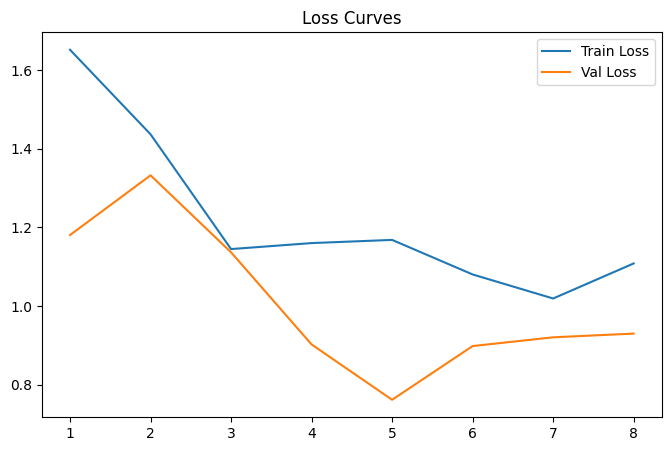

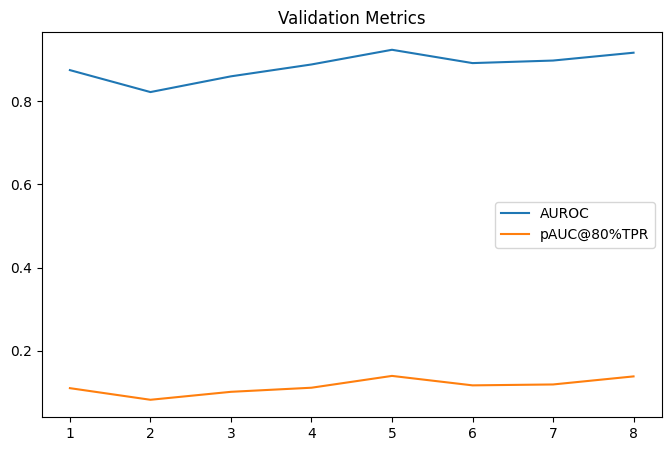

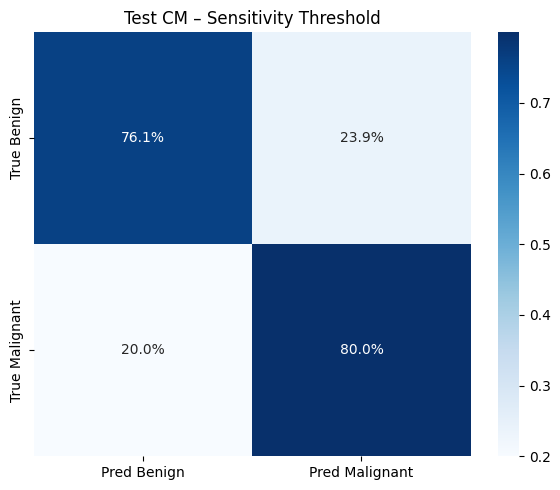

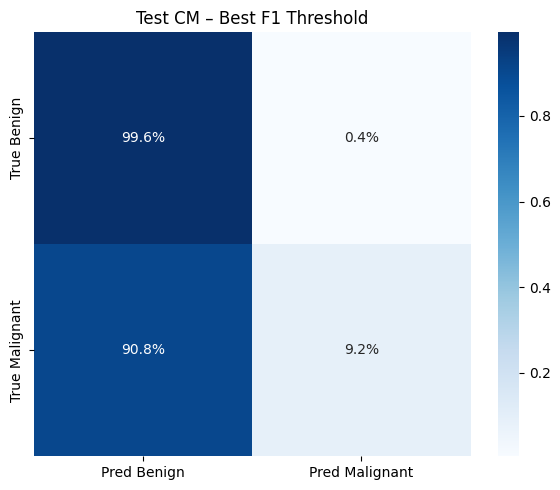


TRAINING FINISHED!
Best model: /kaggle/working/mobilenetv3_fusion_224/mobilenetv3_fusion_best.pth
All outputs saved to: /kaggle/working/mobilenetv3_fusion_224


In [ ]:
final_output = {
    "validation_at_sensitivity_threshold": val_metrics_sens,
    "test_at_sensitivity_threshold": test_metrics_sens,
    "validation_at_best_f1_threshold": val_metrics_f1,
    "test_at_best_f1_threshold": test_metrics_f1,
    "history": history,
}
with open(METRICS_JSON_PATH, "w") as f:
    json.dump(final_output, f, indent=2)

history_df = pd.DataFrame(history)
if len(history_df) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
    plt.title("Loss Curves")
    plt.legend()
    plt.savefig(os.path.join(SAVE_DIR, "loss_curve.png"), dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["val_auroc"], label="AUROC")
    plt.plot(history_df["epoch"], history_df["val_pauc"], label="pAUC@80%TPR")
    plt.title("Validation Metrics")
    plt.legend()
    plt.savefig(os.path.join(SAVE_DIR, "metrics_curve.png"), dpi=200, bbox_inches="tight")
    plt.show()

def plot_cm(cm, title, fname):
    cm_norm = cm.astype(np.float64) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_norm, annot=True, fmt=".1%", cmap="Blues",
        xticklabels=["Pred Benign", "Pred Malignant"],
        yticklabels=["True Benign", "True Malignant"]
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, fname), dpi=200, bbox_inches="tight")
    plt.show()

plot_cm(test_cm_sens, "Test CM – Sensitivity Threshold", "cm_test_sensitivity.png")
plot_cm(test_cm_f1, "Test CM – Best F1 Threshold", "cm_test_best_f1.png")

print("\nTRAINING FINISHED!")
print(f"Best model: {BEST_MODEL_PATH}")
print(f"All outputs saved to: {SAVE_DIR}")